# Flight Delay Risk Estimator — EDA & Model Training

**Problem statement:** Estimate the probability that a US domestic flight arrives 15+ minutes late (the FAA definition of a delayed flight), using only information known at booking time — airline, route, scheduled date/time, and distance.

**Workflow:** load & inspect raw data → clean → feature engineering → EDA → baseline + cross-validated model comparison → benchmark on a held-out test set → select champion → diagnostic evaluation (confusion matrix, ROC/PR curves, threshold tuning) → hyperparameter tuning → save a deployable artifact.

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

DATA_PATH = 'data/flights_sample.csv'
df = pd.read_csv(DATA_PATH, nrows=150000)
print(f"Initial Dataset Shape: {df.shape}")
print("Columns available:", list(df.columns[:32]))

Initial Dataset Shape: (150000, 32)
Columns available: ['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE', 'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   FL_DATE                  150000 non-null  str    
 1   AIRLINE                  150000 non-null  str    
 2   AIRLINE_DOT              150000 non-null  str    
 3   AIRLINE_CODE             150000 non-null  str    
 4   DOT_CODE                 150000 non-null  int64  
 5   FL_NUMBER                150000 non-null  int64  
 6   ORIGIN                   150000 non-null  str    
 7   ORIGIN_CITY              150000 non-null  str    
 8   DEST                     150000 non-null  str    
 9   DEST_CITY                150000 non-null  str    
 10  CRS_DEP_TIME             150000 non-null  int64  
 11  DEP_TIME                 146107 non-null  float64
 12  DEP_DELAY                146104 non-null  float64
 13  TAXI_OUT                 146063 non-null  float64
 14  WHEELS_OFF     

## 2. Data Quality Check (Before Cleaning)

Before transforming anything, it's worth looking at the raw data as-is: how much is missing, are there obvious outliers, and does the target-adjacent column (`ARR_DELAY`) look sane? This catches problems early instead of silently baking them into features.

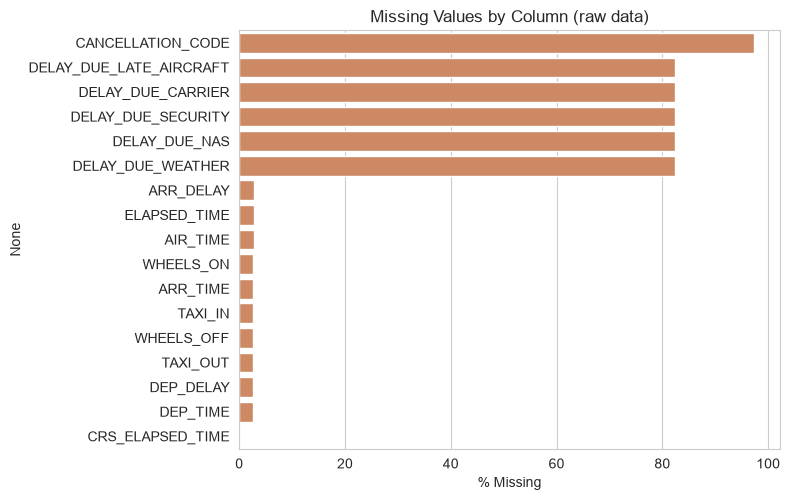

Cancelled / Diverted flight counts:
CANCELLED    3951.0
DIVERTED      326.0
dtype: float64


In [3]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, max(3, len(missing_pct) * 0.3)))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color='#DD8452')
plt.xlabel('% Missing')
plt.title('Missing Values by Column (raw data)')
plt.tight_layout()
plt.show()

print("Cancelled / Diverted flight counts:")
print(df[['CANCELLED', 'DIVERTED']].sum())

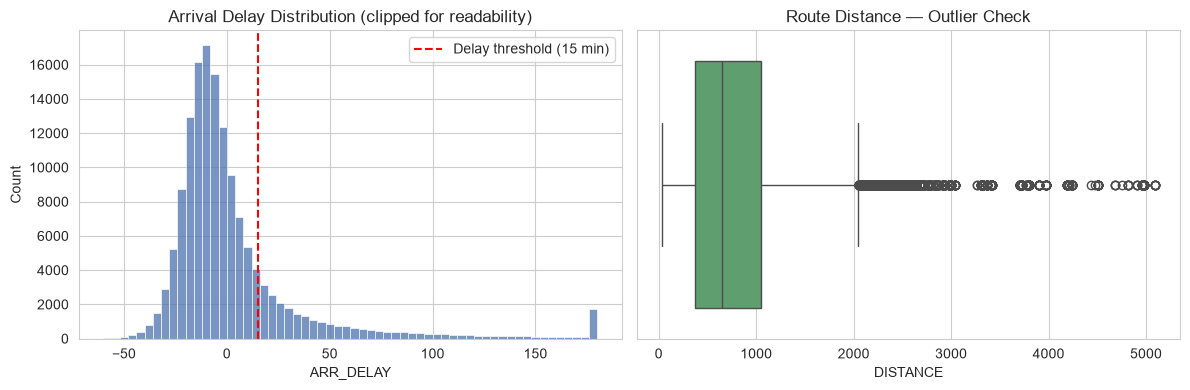

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['ARR_DELAY'].dropna().clip(-60, 180), bins=60, ax=axes[0], color='#4C72B0')
axes[0].axvline(15, color='red', linestyle='--', label='Delay threshold (15 min)')
axes[0].set_title('Arrival Delay Distribution (clipped for readability)')
axes[0].legend()

sns.boxplot(x=df['DISTANCE'], ax=axes[1], color='#55A868')
axes[1].set_title('Route Distance — Outlier Check')

plt.tight_layout()
plt.show()

## 3. Data Cleaning & Feature Engineering

In [5]:
# Standardize column headers
df.columns = df.columns.str.upper().str.strip()

# 1. Filter out Cancelled & Diverted flights
df = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()

# 2. Drop rows missing ARR_DELAY
df = df.dropna(subset=['ARR_DELAY']).copy()

# 3. Target: Delayed >= 15 min (FAA standard)
df['IS_DELAYED'] = (df['ARR_DELAY'] >= 15).astype(int)

# 4. Temporal Features from FL_DATE
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['MONTH'] = df['FL_DATE'].dt.month
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek + 1  # 1 = Monday, 7 = Sunday
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin([6, 7]).astype(int)

# 5. Extract Scheduled Departure Hour (e.g. 630 -> 6, 1845 -> 18)
df['DEP_HOUR'] = (df['CRS_DEP_TIME'] // 100).astype(int).clip(0, 23)

# 6. Route Distance Tier
df['DISTANCE_TIER'] = pd.cut(
    df['DISTANCE'],
    bins=[-np.inf, 500, 1500, np.inf],
    labels=['Short_Haul', 'Medium_Haul', 'Long_Haul']
)
df['ROUTE'] = df['ORIGIN'].astype(str) + '_' + df['DEST'].astype(str)
df['IS_PEAK_SEASON'] = df['MONTH'].isin([6, 7, 8, 11, 12]).astype(int)

# 7. Filter top volume entities to prevent high-cardinality explosion
top_airports = df['ORIGIN'].value_counts().nlargest(20).index
top_destinations = df['DEST'].value_counts().nlargest(20).index
top_carriers = df['AIRLINE'].value_counts().nlargest(10).index

df_clean = df[
    df['ORIGIN'].isin(top_airports) &
    df['DEST'].isin(top_destinations) &
    df['AIRLINE'].isin(top_carriers)
].copy()

# 8. Select modeling features
features = [
    'AIRLINE', 'ORIGIN', 'DEST', 'MONTH', 'DAY_OF_WEEK',
    'DEP_HOUR', 'IS_WEEKEND', 'DISTANCE', 'DISTANCE_TIER', 'ROUTE',
    'IS_PEAK_SEASON'
]
df_clean = df_clean[features + ['IS_DELAYED']].reset_index(drop=True)

print(f"Cleaned Working Dataset Shape: {df_clean.shape}")
df_clean.info()
print("Class Balance (Target):")
print(df_clean['IS_DELAYED'].value_counts(normalize=True))

Cleaned Working Dataset Shape: (26343, 12)
<class 'pandas.DataFrame'>
RangeIndex: 26343 entries, 0 to 26342
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   AIRLINE         26343 non-null  str     
 1   ORIGIN          26343 non-null  str     
 2   DEST            26343 non-null  str     
 3   MONTH           26343 non-null  int32   
 4   DAY_OF_WEEK     26343 non-null  int32   
 5   DEP_HOUR        26343 non-null  int64   
 6   IS_WEEKEND      26343 non-null  int64   
 7   DISTANCE        26343 non-null  float64 
 8   DISTANCE_TIER   26343 non-null  category
 9   ROUTE           26343 non-null  str     
 10  IS_PEAK_SEASON  26343 non-null  int64   
 11  IS_DELAYED      26343 non-null  int64   
dtypes: category(1), float64(1), int32(2), int64(4), str(4)
memory usage: 2.9 MB
Class Balance (Target):
IS_DELAYED
0    0.815549
1    0.184451
Name: proportion, dtype: float64


### 3a. Route Distance Lookup (for the app)

The deployed app needs to compute flight distance automatically from whichever origin/destination the user picks — it shouldn't ask them to type it in, since that could contradict the real route. Build that lookup here, keyed by unordered airport pair (`ATL_BOS` covers both directions, since physical distance doesn't depend on which way you're flying).

In [6]:
pair_key = df_clean.apply(lambda r: '_'.join(sorted([r['ORIGIN'], r['DEST']])), axis=1)
route_distances = df_clean.groupby(pair_key)['DISTANCE'].mean().to_dict()
avg_distance = float(df_clean['DISTANCE'].mean())

print(f"Distance lookup covers {len(route_distances)} unordered airport pairs")
print(f"Fallback average distance (for any unseen pair): {avg_distance:.0f} miles")

Distance lookup covers 180 unordered airport pairs
Fallback average distance (for any unseen pair): 1044 miles


## 4. Exploratory Data Analysis (Post-Cleaning)

Now that features exist, look at how delay rate moves across them before modeling — this is where you form hypotheses about what the model should learn.

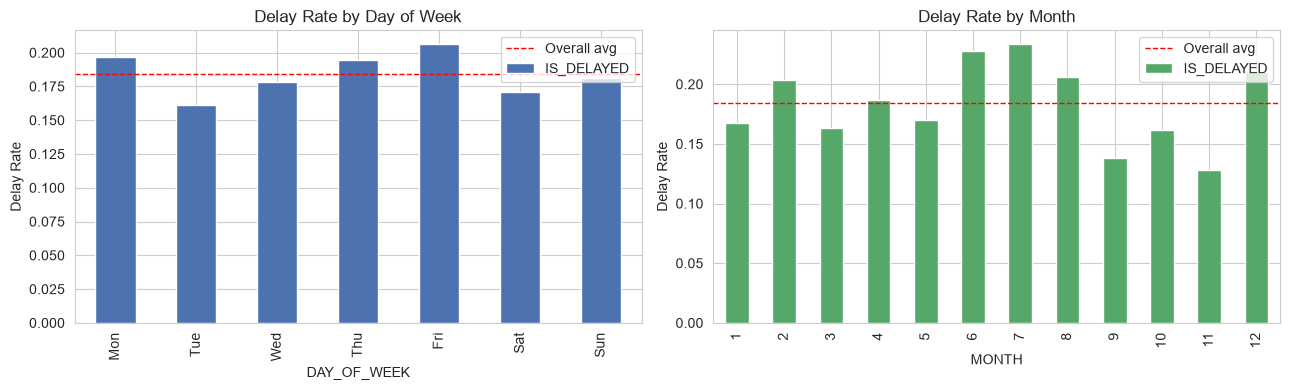

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dow_labels = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow_rate = df_clean.groupby('DAY_OF_WEEK')['IS_DELAYED'].mean().rename(index=dow_labels)
dow_rate.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Delay Rate by Day of Week')
axes[0].set_ylabel('Delay Rate')
axes[0].axhline(df_clean['IS_DELAYED'].mean(), color='red', linestyle='--', linewidth=1, label='Overall avg')
axes[0].legend()

month_rate = df_clean.groupby('MONTH')['IS_DELAYED'].mean()
month_rate.plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Delay Rate by Month')
axes[1].set_ylabel('Delay Rate')
axes[1].axhline(df_clean['IS_DELAYED'].mean(), color='red', linestyle='--', linewidth=1, label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.show()

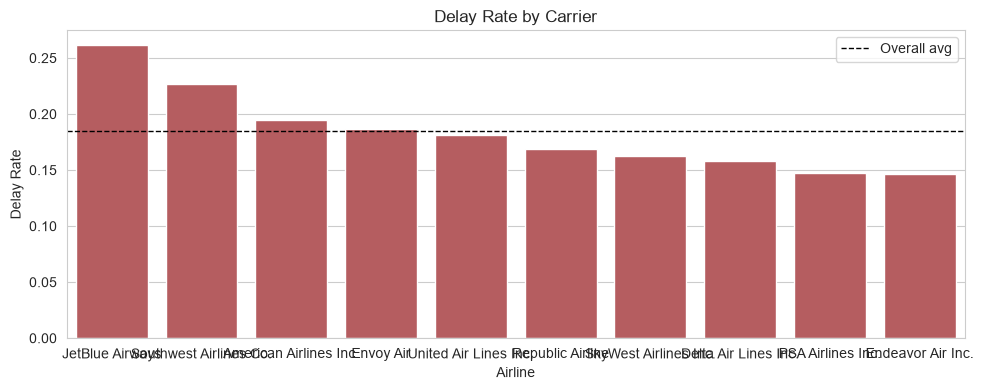

In [8]:
plt.figure(figsize=(10, 4))
carrier_rate = df_clean.groupby('AIRLINE')['IS_DELAYED'].mean().sort_values(ascending=False)
sns.barplot(x=carrier_rate.index, y=carrier_rate.values, color='#C44E52')
plt.axhline(df_clean['IS_DELAYED'].mean(), color='black', linestyle='--', linewidth=1, label='Overall avg')
plt.title('Delay Rate by Carrier')
plt.ylabel('Delay Rate')
plt.xlabel('Airline')
plt.legend()
plt.tight_layout()
plt.show()

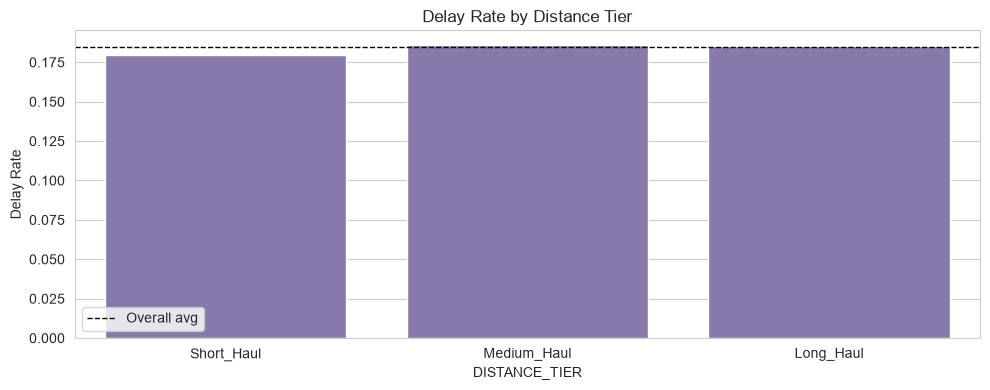

In [9]:
plt.figure(figsize=(10, 4))
tier_rate = df_clean.groupby('DISTANCE_TIER', observed=True)['IS_DELAYED'].mean()
sns.barplot(x=tier_rate.index, y=tier_rate.values, color='#8172B2')
plt.axhline(df_clean['IS_DELAYED'].mean(), color='black', linestyle='--', linewidth=1, label='Overall avg')
plt.title('Delay Rate by Distance Tier')
plt.ylabel('Delay Rate')
plt.legend()
plt.tight_layout()
plt.show()

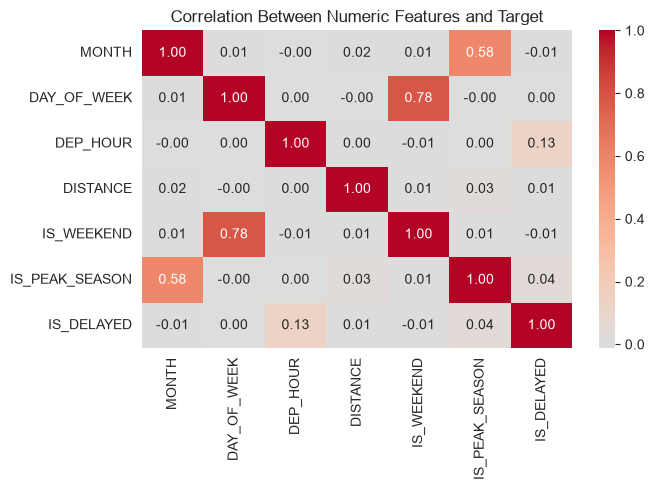

In [10]:
numeric_cols = ['MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'DISTANCE', 'IS_WEEKEND', 'IS_PEAK_SEASON', 'IS_DELAYED']
plt.figure(figsize=(7, 5))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Numeric Features and Target')
plt.tight_layout()
plt.show()

## 5. Train/Test Split & Route Delay Rate

One subtlety worth calling out explicitly: `ROUTE_DELAY_RATE` (the historical delay rate for an `ORIGIN → DEST` pair) is calculated **only from `y_train`**, never from the test set. If we computed it from the full dataset before splitting, the test set would "leak" information about its own labels into a feature — quietly inflating our evaluation metrics. Computing it from training data only, then mapping it onto both train and test, is the correct way to do this.

In [11]:
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

# 1. Feature Separation
X = df_clean.drop(columns=['IS_DELAYED'])
y = df_clean['IS_DELAYED']

# 2. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

global_prior = y_train.mean()
smoothing_weight = 10  # Pulls low-sample routes toward the global mean

# Calculate Smoothed Route Delay Rate on Training Data ONLY
# Formula: (Count * Mean + Weight * Prior) / (Count + Weight)
train_route_stats = y_train.groupby(X_train['ROUTE']).agg(['count', 'mean'])
train_route_rates = (
    (train_route_stats['count'] * train_route_stats['mean'] + smoothing_weight * global_prior) /
    (train_route_stats['count'] + smoothing_weight)
)

X_train['ROUTE_DELAY_RATE'] = X_train['ROUTE'].map(train_route_rates).fillna(global_prior)
X_test['ROUTE_DELAY_RATE'] = X_test['ROUTE'].map(train_route_rates).fillna(global_prior)

X_train = X_train.drop(columns=['ROUTE'])
X_test = X_test.drop(columns=['ROUTE'])

# 3. Define Feature Subsets
num_features = ['MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'DISTANCE', 'ROUTE_DELAY_RATE']
cat_features = ['AIRLINE', 'ORIGIN', 'DEST', 'IS_WEEKEND', 'IS_PEAK_SEASON', 'DISTANCE_TIER']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print(f"Train shape: {X_train.shape}  |  Test shape: {X_test.shape}")
print(f"Base delay rate (train): {global_prior:.4f}")

Train shape: (21074, 11)  |  Test shape: (5269, 11)
Base delay rate (train): 0.1844


## 6. Baseline & Cross-Validation Comparison

Two additions here:

- **Baseline model** — a `DummyClassifier` that guesses using only the class frequencies, with no real features. Every real model must clearly beat this or it isn't earning its complexity.
- **5-fold cross-validation** — instead of trusting one train/test split, we fit and score the model 5 times on different folds of the training data and look at the mean and standard deviation. A small standard deviation means the score is stable; a large one means don't trust the single-split number too much.

*Honest caveat:* `ROUTE_DELAY_RATE` was computed once on the whole training set before this cross-validation, so the CV folds aren't perfectly independent of each other through that one feature — a mild, second-order leakage. A fully rigorous pipeline would recompute the route rate inside every fold. We're flagging this rather than hiding it, since spotting subtle leakage like this is exactly the kind of thing an interviewer will probe on.

In [12]:
candidate_models = {
    'Baseline (stratified guess)': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.08, random_state=42,
        scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
        eval_metric='logloss', n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
for name, clf in candidate_models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'CV ROC-AUC (mean)': round(scores.mean(), 4),
        'CV ROC-AUC (std)': round(scores.std(), 4)
    })

cv_results_df = pd.DataFrame(cv_results)
print("=== 5-Fold Cross-Validation Results ===")
print(cv_results_df.to_string(index=False))

=== 5-Fold Cross-Validation Results ===
                      Model  CV ROC-AUC (mean)  CV ROC-AUC (std)
Baseline (stratified guess)             0.4938            0.0038
        Logistic Regression             0.6485            0.0059
              Random Forest             0.6466            0.0046
                    XGBoost             0.6345            0.0040


## 7. Final Benchmark on the Held-Out Test Set

The CV numbers above tell us which models are *stable*. Now we fit each real model once on the full training set and score it on the untouched test set — this is the number that matters for choosing what actually ships, since it's closest to how the model will be judged in production.

In [13]:
models = {k: v for k, v in candidate_models.items() if k != 'Baseline (stratified guess)'}

results_list = []
fitted_pipelines = {}
for name, clf in models.items():
    print(f"Training {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    pipeline.fit(X_train, y_train)
    fitted_pipelines[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    results_list.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4)
    })

results_df = pd.DataFrame(results_list)
print("\n=== Held-Out Test Set Results ===")
print(results_df.to_string(index=False))
print("\n=== For comparison, 5-Fold CV Results ===")
print(cv_results_df.to_string(index=False))

Training Logistic Regression...
Training Random Forest...
Training XGBoost...

=== Held-Out Test Set Results ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.5931     0.2367  0.5422    0.3296   0.6035
      Random Forest    0.6367     0.2500  0.4846    0.3298   0.6140
            XGBoost    0.6403     0.2531  0.4866    0.3330   0.6094

=== For comparison, 5-Fold CV Results ===
                      Model  CV ROC-AUC (mean)  CV ROC-AUC (std)
Baseline (stratified guess)             0.4938            0.0038
        Logistic Regression             0.6485            0.0059
              Random Forest             0.6466            0.0046
                    XGBoost             0.6345            0.0040


## 8. Model Selection

Select the champion by test-set ROC-AUC (the metric the deployed model is actually judged on), and cross-check it against the CV mean to confirm it isn't an outlier result from a lucky split.

In [14]:
best_row = results_df.sort_values('ROC-AUC', ascending=False).iloc[0]
best_name = best_row['Model']
best_pipeline = fitted_pipelines[best_name]

cv_row = cv_results_df[cv_results_df['Model'] == best_name].iloc[0]

print(f"Champion model: {best_name}")
print(f"Held-out test ROC-AUC: {best_row['ROC-AUC']}")
print(f"5-fold CV ROC-AUC: {cv_row['CV ROC-AUC (mean)']} (+/- {cv_row['CV ROC-AUC (std)']})")

Champion model: Random Forest
Held-out test ROC-AUC: 0.614
5-fold CV ROC-AUC: 0.6466 (+/- 0.0046)


## 9. Diagnostic Plots for the Champion Model

A single ROC-AUC number hides a lot. These three views show *where* the model is right and wrong, which matters a lot more on an imbalanced dataset (18% delayed) than accuracy alone:

- **Confusion matrix** — raw counts of correct/incorrect predictions per class.
- **ROC curve** — true positive rate vs. false positive rate across every possible threshold.
- **Precision-Recall curve** — often more informative than ROC on imbalanced data, since it focuses on how the model performs specifically on the minority (delayed) class.

              precision    recall  f1-score   support

     On-Time       0.85      0.67      0.75      4297
     Delayed       0.25      0.48      0.33       972

    accuracy                           0.64      5269
   macro avg       0.55      0.58      0.54      5269
weighted avg       0.74      0.64      0.67      5269



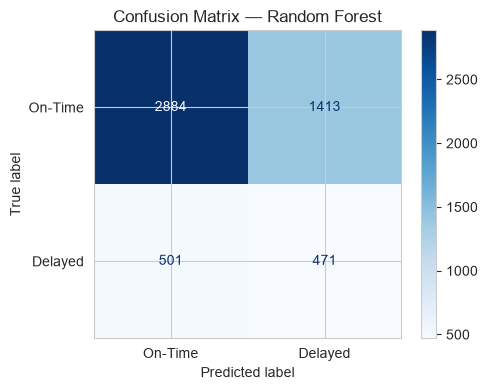

In [15]:
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['On-Time', 'Delayed']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['On-Time', 'Delayed'], cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

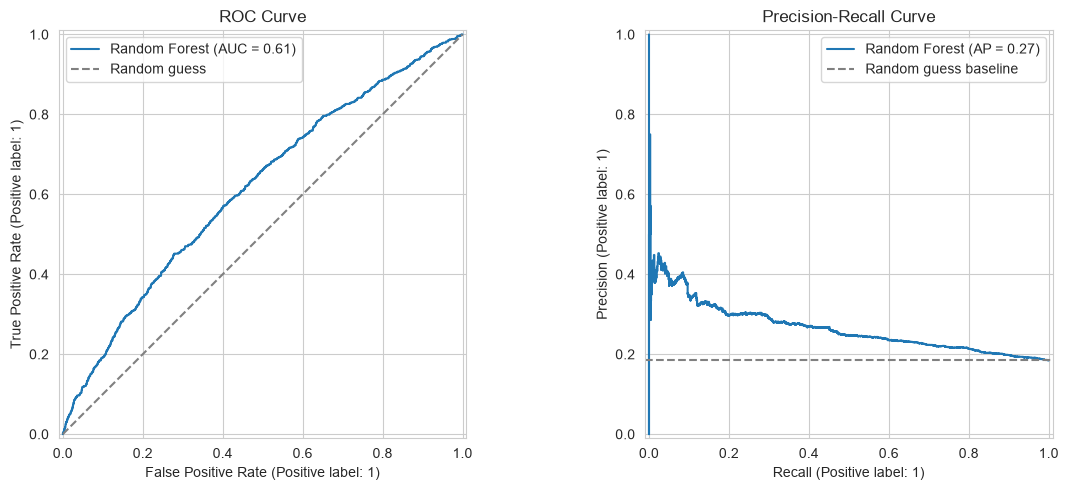

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name=best_name)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
axes[0].set_title('ROC Curve')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=best_name)
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='Random guess baseline')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Threshold Tuning

`predict()` uses a 0.5 probability cutoff by default to decide "delayed" vs "on-time" — but 0.5 is arbitrary, not something the model chose for a reason. Depending on what the risk tool is *for*, you might prefer a different cutoff:

- Lower threshold → catches more true delays (higher recall) but flags more flights that turn out fine (lower precision)
- Higher threshold → fewer false alarms, but misses more real delays

Below we scan thresholds and find the one that maximizes F1 (the balance point), so the final threshold is a deliberate choice, not a default.

Default threshold: 0.50  ->  F1 at default: 0.3298
Best threshold by F1: 0.450  ->  F1 at best threshold: 0.3425
  Precision at best threshold: 0.2298
  Recall at best threshold: 0.6718


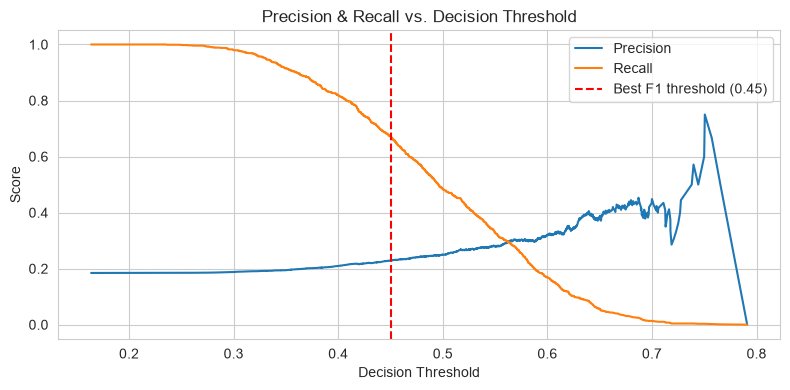

In [17]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Default threshold: 0.50  ->  F1 at default: {f1_score(y_test, y_pred):.4f}")
print(f"Best threshold by F1: {best_threshold:.3f}  ->  F1 at best threshold: {f1_scores[best_idx]:.4f}")
print(f"  Precision at best threshold: {precisions[best_idx]:.4f}")
print(f"  Recall at best threshold: {recalls[best_idx]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best F1 threshold ({best_threshold:.2f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs. Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning

So far every model used hand-picked default-ish parameters. `RandomizedSearchCV` tries a random sample of combinations from a defined search space, scores each with cross-validation, and returns the best one — a systematic (if not exhaustive) search rather than guessing.

We only keep the tuned version if it actually beats the original on the held-out test set — tuning can overfit the cross-validation folds, so it's not automatically better.

In [18]:
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10],
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [6, 10, 14, None],
        'classifier__min_samples_leaf': [1, 3, 5],
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 150, 250],
        'classifier__max_depth': [4, 6, 8],
        'classifier__learning_rate': [0.03, 0.08, 0.15],
        'classifier__subsample': [0.7, 0.85, 1.0],
    },
}

if best_name in param_grids:
    search = RandomizedSearchCV(
        estimator=fitted_pipelines[best_name],
        param_distributions=param_grids[best_name],
        n_iter=8, scoring='roc_auc', cv=3, random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train)
    tuned_pipeline = search.best_estimator_

    tuned_proba = tuned_pipeline.predict_proba(X_test)[:, 1]
    tuned_auc = roc_auc_score(y_test, tuned_proba)
    original_auc = best_row['ROC-AUC']

    print(f"Best params found: {search.best_params_}")
    print(f"Untuned {best_name} test ROC-AUC: {original_auc:.4f}")
    print(f"Tuned {best_name} test ROC-AUC:   {tuned_auc:.4f}")

    if tuned_auc > original_auc:
        final_pipeline = tuned_pipeline
        print(f"\n-> Using the TUNED pipeline for deployment (+{tuned_auc - original_auc:.4f} ROC-AUC).")
    else:
        final_pipeline = best_pipeline
        print("\n-> Tuning did not beat the defaults on the test set — keeping the original pipeline.")
else:
    final_pipeline = best_pipeline
    print(f"No tuning grid defined for {best_name}; using default hyperparameters.")

Best params found: {'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 5, 'classifier__max_depth': 10}
Untuned Random Forest test ROC-AUC: 0.6140
Tuned Random Forest test ROC-AUC:   0.6154

-> Using the TUNED pipeline for deployment (+0.0014 ROC-AUC).


## 12. Feature Importance

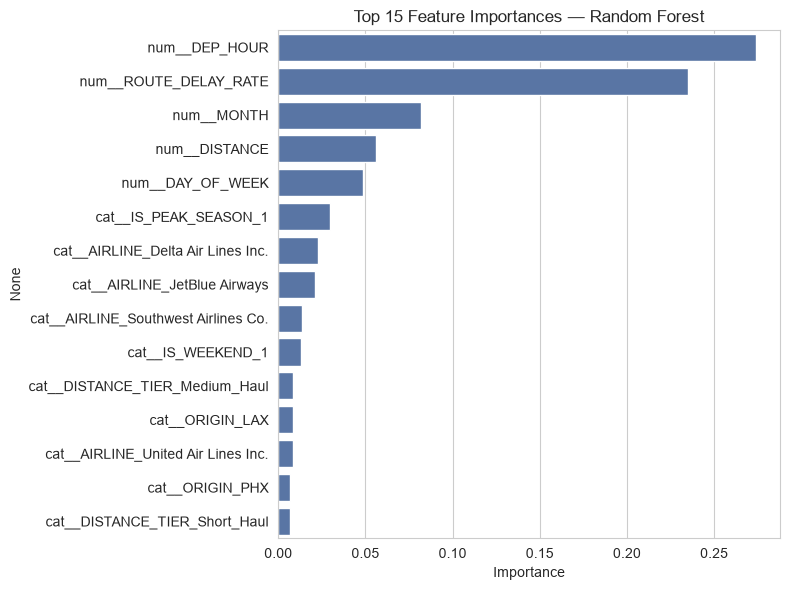

In [19]:
clf = final_pipeline.named_steps['classifier']
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()

if hasattr(clf, 'feature_importances_'):
    importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, color='#4C72B0')
    plt.title(f'Top 15 Feature Importances — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(clf, 'coef_'):
    coefs = pd.Series(clf.coef_[0], index=feature_names).sort_values(key=abs, ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=coefs.values, y=coefs.index, color='#4C72B0')
    plt.title(f'Top 15 Coefficients (abs value) — {best_name}')
    plt.xlabel('Coefficient')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} does not expose feature importances or coefficients.")

## 13. Save Deployment Artifact

Bundle the final pipeline, the route delay-rate lookup, the dropdown option lists, and the tuned decision threshold into a single `joblib` file that `app.py` loads for live predictions.

In [20]:
artifact = {
    'pipeline': final_pipeline,
    'best_model_name': best_name,
    'route_rates': train_route_rates.to_dict(),
    'route_distances': route_distances,
    'avg_distance': avg_distance,
    'global_prior': float(global_prior),
    'top_airports': sorted(top_airports.tolist()),
    'top_destinations': sorted(top_destinations.tolist()),
    'top_carriers': sorted(top_carriers.tolist()),
    'num_features': num_features,
    'cat_features': cat_features,
    'distance_tier_bins': [-np.inf, 500, 1500, np.inf],
    'distance_tier_labels': ['Short_Haul', 'Medium_Haul', 'Long_Haul'],
    'peak_months': [6, 7, 8, 11, 12],
    'weekend_days': [6, 7],
    'results_df': results_df,
    'cv_results_df': cv_results_df,
    'base_delay_rate': float(global_prior),
    'recommended_threshold': float(best_threshold),
}

joblib.dump(artifact, 'model_artifacts.joblib')
print("Saved deployable artifact -> model_artifacts.joblib")

Saved deployable artifact -> model_artifacts.joblib


## Key Takeaways

- **A baseline matters.** Without the dummy classifier for reference, 64% accuracy sounds better than it is on an 82/18 imbalanced target.
- **One split can mislead you.** Cross-validation gives a mean and a standard deviation, not just a single lucky (or unlucky) number.
- **Watch for leakage.** `ROUTE_DELAY_RATE` was computed from training data only — and even then, we called out the residual leakage into the CV folds rather than pretending the pipeline was perfectly clean.
- **Accuracy alone hides class imbalance problems.** The confusion matrix and precision-recall curve tell a fuller story than a single scalar.
- **The 0.5 threshold is a default, not a law.** Tuning it to the F1-optimal point is a deliberate modeling decision.
- **Tuning isn't automatically better.** We only kept the hyperparameter-tuned model because it beat the original on the untouched test set — not just on cross-validation.

These are the same questions an interviewer is likely to ask about *any* classification project — having the answers already in the notebook turns a Q&A risk into a strength.